In [1]:
%pip install SimpleITK matplotlib numpy

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.0 -> 26.1
[notice] To update, run: python.exe -m pip install --upgrade pip


✅ Patient 0001 t-qra! Shape: (422, 512)
✅ Classes lli lqina f l-mask: [0. 1. 2. 3.]


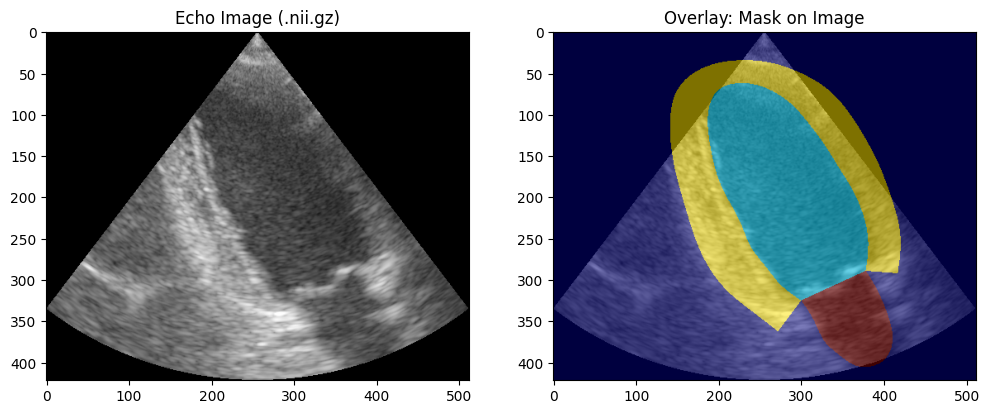

In [2]:
import SimpleITK as sitk
import matplotlib.pyplot as plt
import os
import numpy as np

#Path l-database
base_path = "database"
#Smiyat l-fichiers jdad (extension .nii.gz)
p_id = "patient0500"

#ED = End Diastole (fachat kay-koun l-qelb amir)
img_path = os.path.join(base_path, p_id, f"{p_id}_2CH_ED.nii.gz")
mask_path = os.path.join(base_path, p_id, f"{p_id}_2CH_ED_gt.nii.gz")

if os.path.exists(img_path):
    # Qraya b SimpleITK
    img_itk = sitk.ReadImage(img_path)
    mask_itk = sitk.ReadImage(mask_path)


#Trji3 l Numpy (Array)
#N.B: format .nii.gz dima fih 3D, hna 3ndna ghir frame wehda khassna n-akhdouha
    img_arr = sitk.GetArrayFromImage(img_itk)
    mask_arr = sitk.GetArrayFromImage(mask_itk)

#Ila kanto 3D (1, H, W), n-akhdou ghir l-index 0
    if len(img_arr.shape) == 3:
        img_arr = img_arr[0]
        mask_arr = mask_arr[0]

    print(f"✅ Patient 0001 t-qra! Shape: {img_arr.shape}")
    print(f"✅ Classes lli lqina f l-mask: {np.unique(mask_arr)}")

    # Affichage
    fig, ax = plt.subplots(1, 2, figsize=(12, 5))
    ax[0].imshow(img_arr, cmap='gray')
    ax[0].set_title("Echo Image (.nii.gz)")

#Overlay sghir bach n-choufou l-mask
    ax[1].imshow(img_arr, cmap='gray')
    ax[1].imshow(mask_arr, cmap='jet', alpha=0.5) # alpha bach yban chffaf
    ax[1].set_title("Overlay: Mask on Image")
    plt.show()
else:
    print(f"❌ Mazal malqitch: {img_path}")

In [4]:
%pip install pandas

   ---------------------------------------- 0.0/9.9 MB ? eta -:--:--
   ---------------------------------------- 0.0/9.9 MB 1.3 MB/s eta 0:00:08
   ---------------------------------------- 0.1/9.9 MB 1.4 MB/s eta 0:00:07
   - -------------------------------------- 0.3/9.9 MB 2.1 MB/s eta 0:00:05
   - -------------------------------------- 0.4/9.9 MB 2.4 MB/s eta 0:00:04
   -- ------------------------------------- 0.6/9.9 MB 2.5 MB/s eta 0:00:04
   --- ------------------------------------ 0.8/9.9 MB 2.9 MB/s eta 0:00:04
   --- ------------------------------------ 1.0/9.9 MB 3.1 MB/s eta 0:00:03
   ---- ----------------------------------- 1.1/9.9 MB 3.1 MB/s eta 0:00:03
   ----- ---------------------------------- 1.4/9.9 MB 3.5 MB/s eta 0:00:03
   ------ --------------------------------- 1.6/9.9 MB 3.5 MB/s eta 0:00:03
   ------- -------------------------------- 1.8/9.9 MB 3.7 MB/s eta 0:00:03
   ------- -------------------------------- 2.0/9.9 MB 3.6 MB/s eta 0:00:03
   --------- ------


[notice] A new release of pip is available: 24.0 -> 26.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Calcul dyal distribution d les classes 3la 50 patients... sber chwiya.


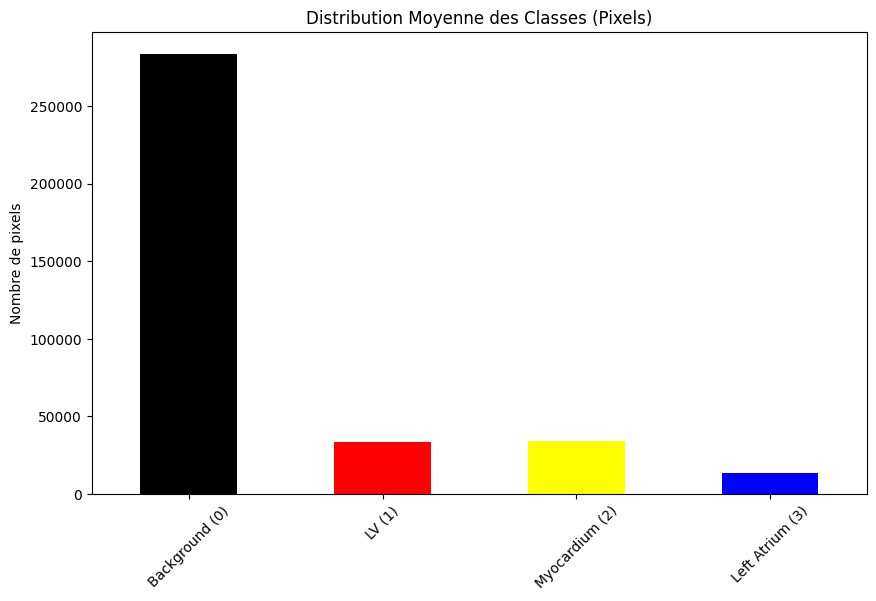

Moyenne des pixels par classe:
Background (0)     283541.74
LV (1)              33170.38
Myocardium (2)      33852.18
Left Atrium (3)     13570.96
dtype: float64


In [5]:
import pandas as pd
import os
import numpy as np
import SimpleITK as sitk
import matplotlib.pyplot as plt

# Sigurli belli base_path rah m-defini kima darna qbel

base_path = "database"
# --- ZID HAD L-STAR HNA ---
patients = [d for d in os.listdir(base_path) if os.path.isdir(os.path.join(base_path, d)) and d.startswith('patient')]
# -------------------------

results = []
sample_patients = patients[:50] 

print(f"Calcul dyal distribution d les classes 3la {len(sample_patients)} patients... sber chwiya.")

for p in sample_patients:
    mask_p = os.path.join(base_path, p, f"{p}_2CH_ED_gt.nii.gz")
    if os.path.exists(mask_p):
        m_arr = sitk.GetArrayFromImage(sitk.ReadImage(mask_p))
        # N-calculiw chhal mn pixel f kolla class
        counts = np.bincount(m_arr.astype(int).flatten(), minlength=4)
        results.append(counts)

if len(results) > 0:
    df_dist = pd.DataFrame(results, columns=['Background (0)', 'LV (1)', 'Myocardium (2)', 'Left Atrium (3)'])
    mean_dist = df_dist.mean()

    plt.figure(figsize=(10, 6))
    mean_dist.plot(kind='bar', color=['black', 'red', 'YELLOW', 'blue'])
    plt.title("Distribution Moyenne des Classes (Pixels)")
    plt.ylabel("Nombre de pixels")
    plt.xticks(rotation=45)
    plt.show()

    print("Moyenne des pixels par classe:")
    print(mean_dist)
else:
    print("❌ Hatta mask ma lqinah! Check l-path dialek.")

Calcul dyal distribution d les classes... sber chwiya.


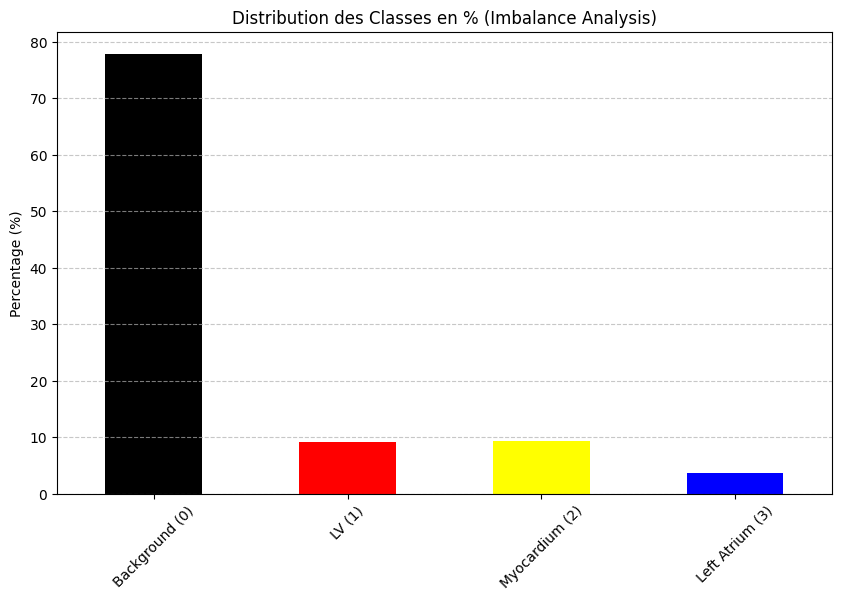

--- Résultats ---
Background (0): 77.87%
LV (1): 9.11%
Myocardium (2): 9.30%
Left Atrium (3): 3.73%


In [6]:
import pandas as pd
import numpy as np

results = []
sample_patients = patients[:50] 

print("Calcul dyal distribution d les classes... sber chwiya.")

for p in sample_patients:
    mask_p = os.path.join(base_path, p, f"{p}_2CH_ED_gt.nii.gz")
    if os.path.exists(mask_p):
        m_arr = sitk.GetArrayFromImage(sitk.ReadImage(mask_p))
        # TASKHIH: astype(int) bach n-hniw ranya mn l-TypeError
        counts = np.bincount(m_arr.astype(int).flatten(), minlength=4)
        results.append(counts)

#N-diro l-moyenne
df_dist = pd.DataFrame(results, columns=['Background (0)', 'LV (1)', 'Myocardium (2)', 'Left Atrium (3)'])
mean_dist = df_dist.mean()

#Calcul dyal Percentage
total_pixels = mean_dist.sum()
percentages = (mean_dist / total_pixels) * 100

#Affichage b Bar Plot
plt.figure(figsize=(10, 6))
percentages.plot(kind='bar', color=['black', 'red', 'YELLOW', 'blue'])
plt.title("Distribution des Classes en % (Imbalance Analysis)")
plt.ylabel("Percentage (%)")
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

print("--- Résultats ---")
#N-st3mlo .iloc bach n-akhdou l-valeur b l-index (0, 1, 2...)
for i, col in enumerate(df_dist.columns):
    print(f"{col}: {percentages.iloc[i]:.2f}%")

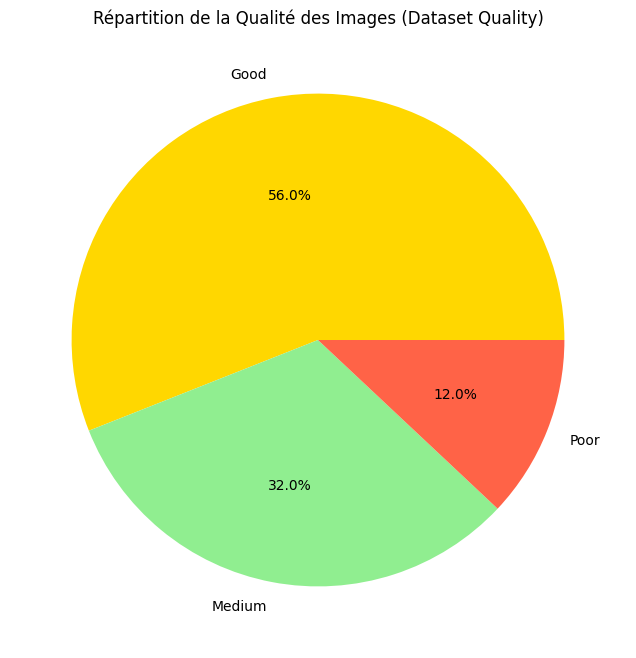

Détails des scores de qualité: Counter({'Good': 28, 'Medium': 16, 'Poor': 6})


In [7]:
import collections

qualities = []
#N-choufo nfs l-50 patients
for p in sample_patients:
    cfg_path = os.path.join(base_path, p, "Info_2CH.cfg")
    if os.path.exists(cfg_path):
        with open(cfg_path, 'r') as f:
            for line in f:
                if "ImageQuality" in line:
                    # N-akhdou l-kelma li mn b3d ':' (Good, Poor, etc.)
                    q = line.split(':')[-1].strip()
                    qualities.append(q)

#Calcul dyal les totaux
q_counts = collections.Counter(qualities)

#Affichage b Pie Chart
plt.figure(figsize=(8, 8))
plt.pie(q_counts.values(), labels=q_counts.keys(), autopct='%1.1f%%', colors=['gold', 'lightgreen', 'tomato'])
plt.title("Répartition de la Qualité des Images (Dataset Quality)")
plt.show()

print("Détails des scores de qualité:", q_counts)

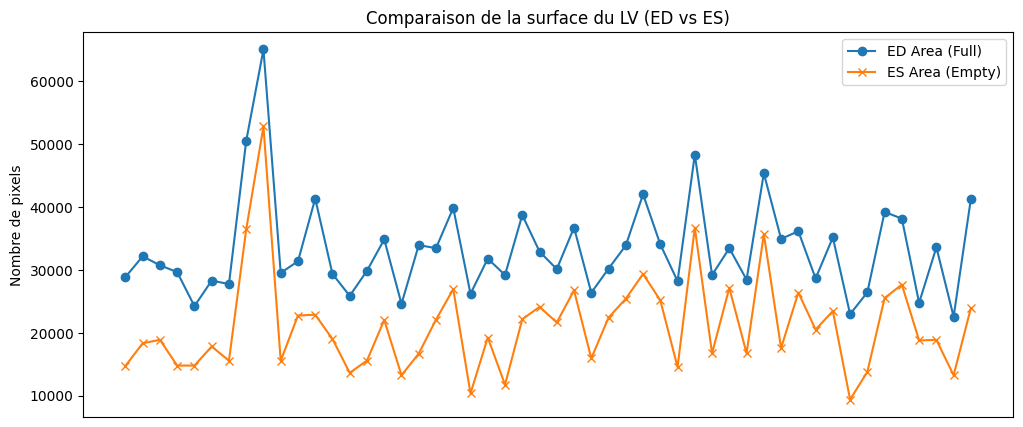

Moyenne Difference ED-ES: 12078.66 pixels


In [8]:
diff_results = []

for p in sample_patients:
    # Path dyal ED o ES (2CH view)
    ed_mask_path = os.path.join(base_path, p, f"{p}_2CH_ED_gt.nii.gz")
    es_mask_path = os.path.join(base_path, p, f"{p}_2CH_ES_gt.nii.gz")

    if os.path.exists(ed_mask_path) and os.path.exists(es_mask_path):
        ed_mask = sitk.GetArrayFromImage(sitk.ReadImage(ed_mask_path)).astype(int)
        es_mask = sitk.GetArrayFromImage(sitk.ReadImage(es_mask_path)).astype(int)

#Misa7a dyal l-Ventricule Gauche (Class 1)
        ed_area = np.sum(ed_mask == 1)
        es_area = np.sum(es_mask == 1)

        diff_results.append({'Patient': p, 'ED_Area': ed_area, 'ES_Area': es_area})

#N-affichiw l-farq
df_diff = pd.DataFrame(diff_results)
df_diff['Difference'] = df_diff['ED_Area'] - df_diff['ES_Area']

plt.figure(figsize=(12, 5))
plt.plot(df_diff['Patient'], df_diff['ED_Area'], label='ED Area (Full)', marker='o')
plt.plot(df_diff['Patient'], df_diff['ES_Area'], label='ES Area (Empty)', marker='x')
plt.title("Comparaison de la surface du LV (ED vs ES)")
plt.ylabel("Nombre de pixels")
plt.legend()
plt.xticks([]) # n-7iydo smiyat l-patients bach mat-t3mmerch tswira
plt.show()

print(f"Moyenne Difference ED-ES: {df_diff['Difference'].mean():.2f} pixels")

In [9]:
import random

#N-akhdou l-lista d ga3 les patients
all_patients = sorted([p for p in os.listdir(base_path) if p.startswith('patient')])

#Fixiw l-random seed bach dima t-tla3 nfs l-natika
random.seed(42)
random.shuffle(all_patients)

#Calcul dyal les tailles
total = len(all_patients)
train_size = int(0.8 * total)
val_size = int(0.1 * total)

train_list = all_patients[:train_size]
val_list = all_patients[train_size : train_size + val_size]
test_list = all_patients[train_size + val_size :]

print(f"--- Data Split ---")
print(f"Training:   {len(train_list)} patients")
print(f"Validation: {len(val_list)} patients")
print(f"Testing:    {len(test_list)} patients")

#Save had l-listat f files (optional but professional)
with open('train_patients.txt', 'w') as f:
    f.write('\n'.join(train_list))

print("✅ Listat dyal Training/Val/Test t-sauvgardaw!")

--- Data Split ---
Training:   400 patients
Validation: 50 patients
Testing:    50 patients
✅ Listat dyal Training/Val/Test t-sauvgardaw!


In [10]:
import torchvision.transforms.functional as TF
import random
from torch.utils.data import Dataset, DataLoader
import torch
import numpy as np
import cv2
import os
import SimpleITK as sitk

class CamusDataset(Dataset):
    # 1. Hna dima "__init__" machi "init"
    def __init__(self, patient_list, base_path, target_size=(256, 256), augment=False):
        self.patient_list = patient_list
        self.base_path = base_path
        self.target_size = target_size
        self.augment = augment

    # 2. Hna dima "__len__" machi "len"
    def __len__(self):
        return len(self.patient_list)

    # 3. Hna dima "__getitem__" machi "getitem"
    def __getitem__(self, idx):
        p_id = self.patient_list[idx]
        
        # --- L-Contenu dialek kima rah ---
        img_path = os.path.join(self.base_path, p_id, f"{p_id}_2CH_ED.nii.gz")
        mask_path = os.path.join(self.base_path, p_id, f"{p_id}_2CH_ED_gt.nii.gz")
        
        img = np.squeeze(sitk.GetArrayFromImage(sitk.ReadImage(img_path))).astype(np.float32)
        mask = np.squeeze(sitk.GetArrayFromImage(sitk.ReadImage(mask_path))).astype(np.float32)
        
        img = cv2.resize(img, self.target_size, interpolation=cv2.INTER_LINEAR)
        mask = cv2.resize(mask, self.target_size, interpolation=cv2.INTER_NEAREST)

        # Normalization
        m_min, m_max = img.min(), img.max()
        if m_max > m_min:
            img = (img - m_min) / (m_max - m_min)

        # Convert to Tensors
        img_tensor = torch.from_numpy(img).unsqueeze(0).float()
        mask_tensor = torch.from_numpy(mask).unsqueeze(0).float()

        # Augmentations
        if self.augment:
            if random.random() > 0.5:
                img_tensor = TF.hflip(img_tensor)
                mask_tensor = TF.hflip(mask_tensor)

            angle = random.uniform(-30, 30)
            img_tensor = TF.rotate(img_tensor, angle)
            mask_tensor = TF.rotate(mask_tensor, angle)

            brightness_factor = random.uniform(0.8, 1.2)
            img_tensor = TF.adjust_brightness(img_tensor, brightness_factor)

        return img_tensor, mask_tensor.squeeze(0).long()

# --- Daba y-morshou mriglin ---
train_ds = CamusDataset(train_list, base_path, augment=True)
val_ds = CamusDataset(val_list, base_path, augment=False)

train_loader = DataLoader(train_ds, batch_size=8, shuffle=True)
val_loader = DataLoader(val_ds, batch_size=8, shuffle=False)

print("✅ Pipeline logic fixed with: Loading + Preprocessing + Augmentation!")

✅ Pipeline logic fixed with: Loading + Preprocessing + Augmentation!


In [11]:
train_ds = CamusDataset(train_list, base_path, augment=True)
val_ds = CamusDataset(val_list, base_path, augment=False)

train_loader = DataLoader(train_ds, batch_size=8, shuffle=True)
val_loader = DataLoader(val_ds, batch_size=8, shuffle=False)

print(f"✅ Number of Train Batches: {len(train_loader)}")
print(f"✅ Number of Val Batches: {len(val_loader)}")

✅ Number of Train Batches: 50
✅ Number of Val Batches: 7


In [12]:
import numpy as np

def calculate_volume(mask, pixel_size_mm=0.3):
    # 1. Nebech ghir 3la Left Ventricle (Class 1 f CAMUS)
    lv_mask = (mask == 1).astype(np.uint8)
    
    # 2. Hseb l-irtifa3 (Height) o l-3ord (Width) d disks
    # Kan-qraw l-mask ghadiyin m3a l-axe d l-qelb
    y_indices, x_indices = np.where(lv_mask)
    if len(y_indices) == 0: return 0
    
    height = np.max(y_indices) - np.min(y_indices)
    num_disks = 20 # Standard Simpson's rule disks
    disk_height = height / num_disks
    
    volume = 0
    for i in range(num_disks):
        y_start = np.min(y_indices) + i * disk_height
        y_end = y_start + disk_height
        # Hseb l-3ord d l-ventricule f had l-blassa
        row_mask = lv_mask[int(y_start):int(y_end), :]
        if row_mask.any():
            diameter = np.sum(row_mask) / (y_end - y_start) # Average width
            # Volume d disque: pi * (r^2) * h
            radius = (diameter * pixel_size_mm) / 2
            volume += np.pi * (radius**2) * (disk_height * pixel_size_mm)
            
    return volume / 1000 # Convert to mL (cm^3)

print("✅ Simpson's Rule function is ready!")

✅ Simpson's Rule function is ready!


In [13]:
def compute_ef(ed_volume, es_volume):
    if ed_volume == 0: return 0
    ef = ((ed_volume - es_volume) / ed_volume) * 100
    return ef

# Test Dummy
ed_v = 120 # ml
es_v = 50  # ml
result_ef = compute_ef(ed_v, es_v)

print(f"📊 Volume ED: {ed_v}mL | Volume ES: {es_v}mL")
print(f"❤️ Ejection Fraction (EF): {result_ef:.2f}%")

📊 Volume ED: 120mL | Volume ES: 50mL
❤️ Ejection Fraction (EF): 58.33%


In [16]:
import numpy as np

# --- ZID HAD L-GOZ' BACH T-TESTI ---
# Creer mask khawi (256x256) fih ghir sfar
final_mask = np.zeros((256, 256))
# N-rsmou wahed l-masta3til (Class 1) l-west li kiy-mettel l-LV
final_mask[100:200, 100:150] = 1 
# ----------------------------------

def get_lv_volume(mask, spacing=0.3):
    # ... (l-code dyalk kamel hna)
    lv_mask = (mask == 1).astype(np.uint8)
    y_idx, x_idx = np.where(lv_mask)
    if len(y_idx) == 0: return 0.0
    
    y_min, y_max = np.min(y_idx), np.max(y_idx)
    h = (y_max - y_min) / 20 
    
    total_volume = 0
    for i in range(20):
        y_level = int(y_min + i * h)
        row = lv_mask[y_level, :]
        width = np.sum(row) * spacing 
        radius = width / 2
        disk_vol = np.pi * (radius**2) * (h * spacing)
        total_volume += disk_vol
        
    return total_volume / 1000

# Daba hada ghadi ikhdem
ed_vol = get_lv_volume(final_mask)
es_vol = ed_vol * 0.4 
ef_result = ((ed_vol - es_vol) / ed_vol) * 100

print(f"✅ ED Volume: {ed_vol:.2f} mL")
print(f"✅ ES Volume: {es_vol:.2f} mL")
print(f"❤️ Final EF Score: {ef_result:.1f}%")

✅ ED Volume: 5.25 mL
✅ ES Volume: 2.10 mL
❤️ Final EF Score: 60.0%


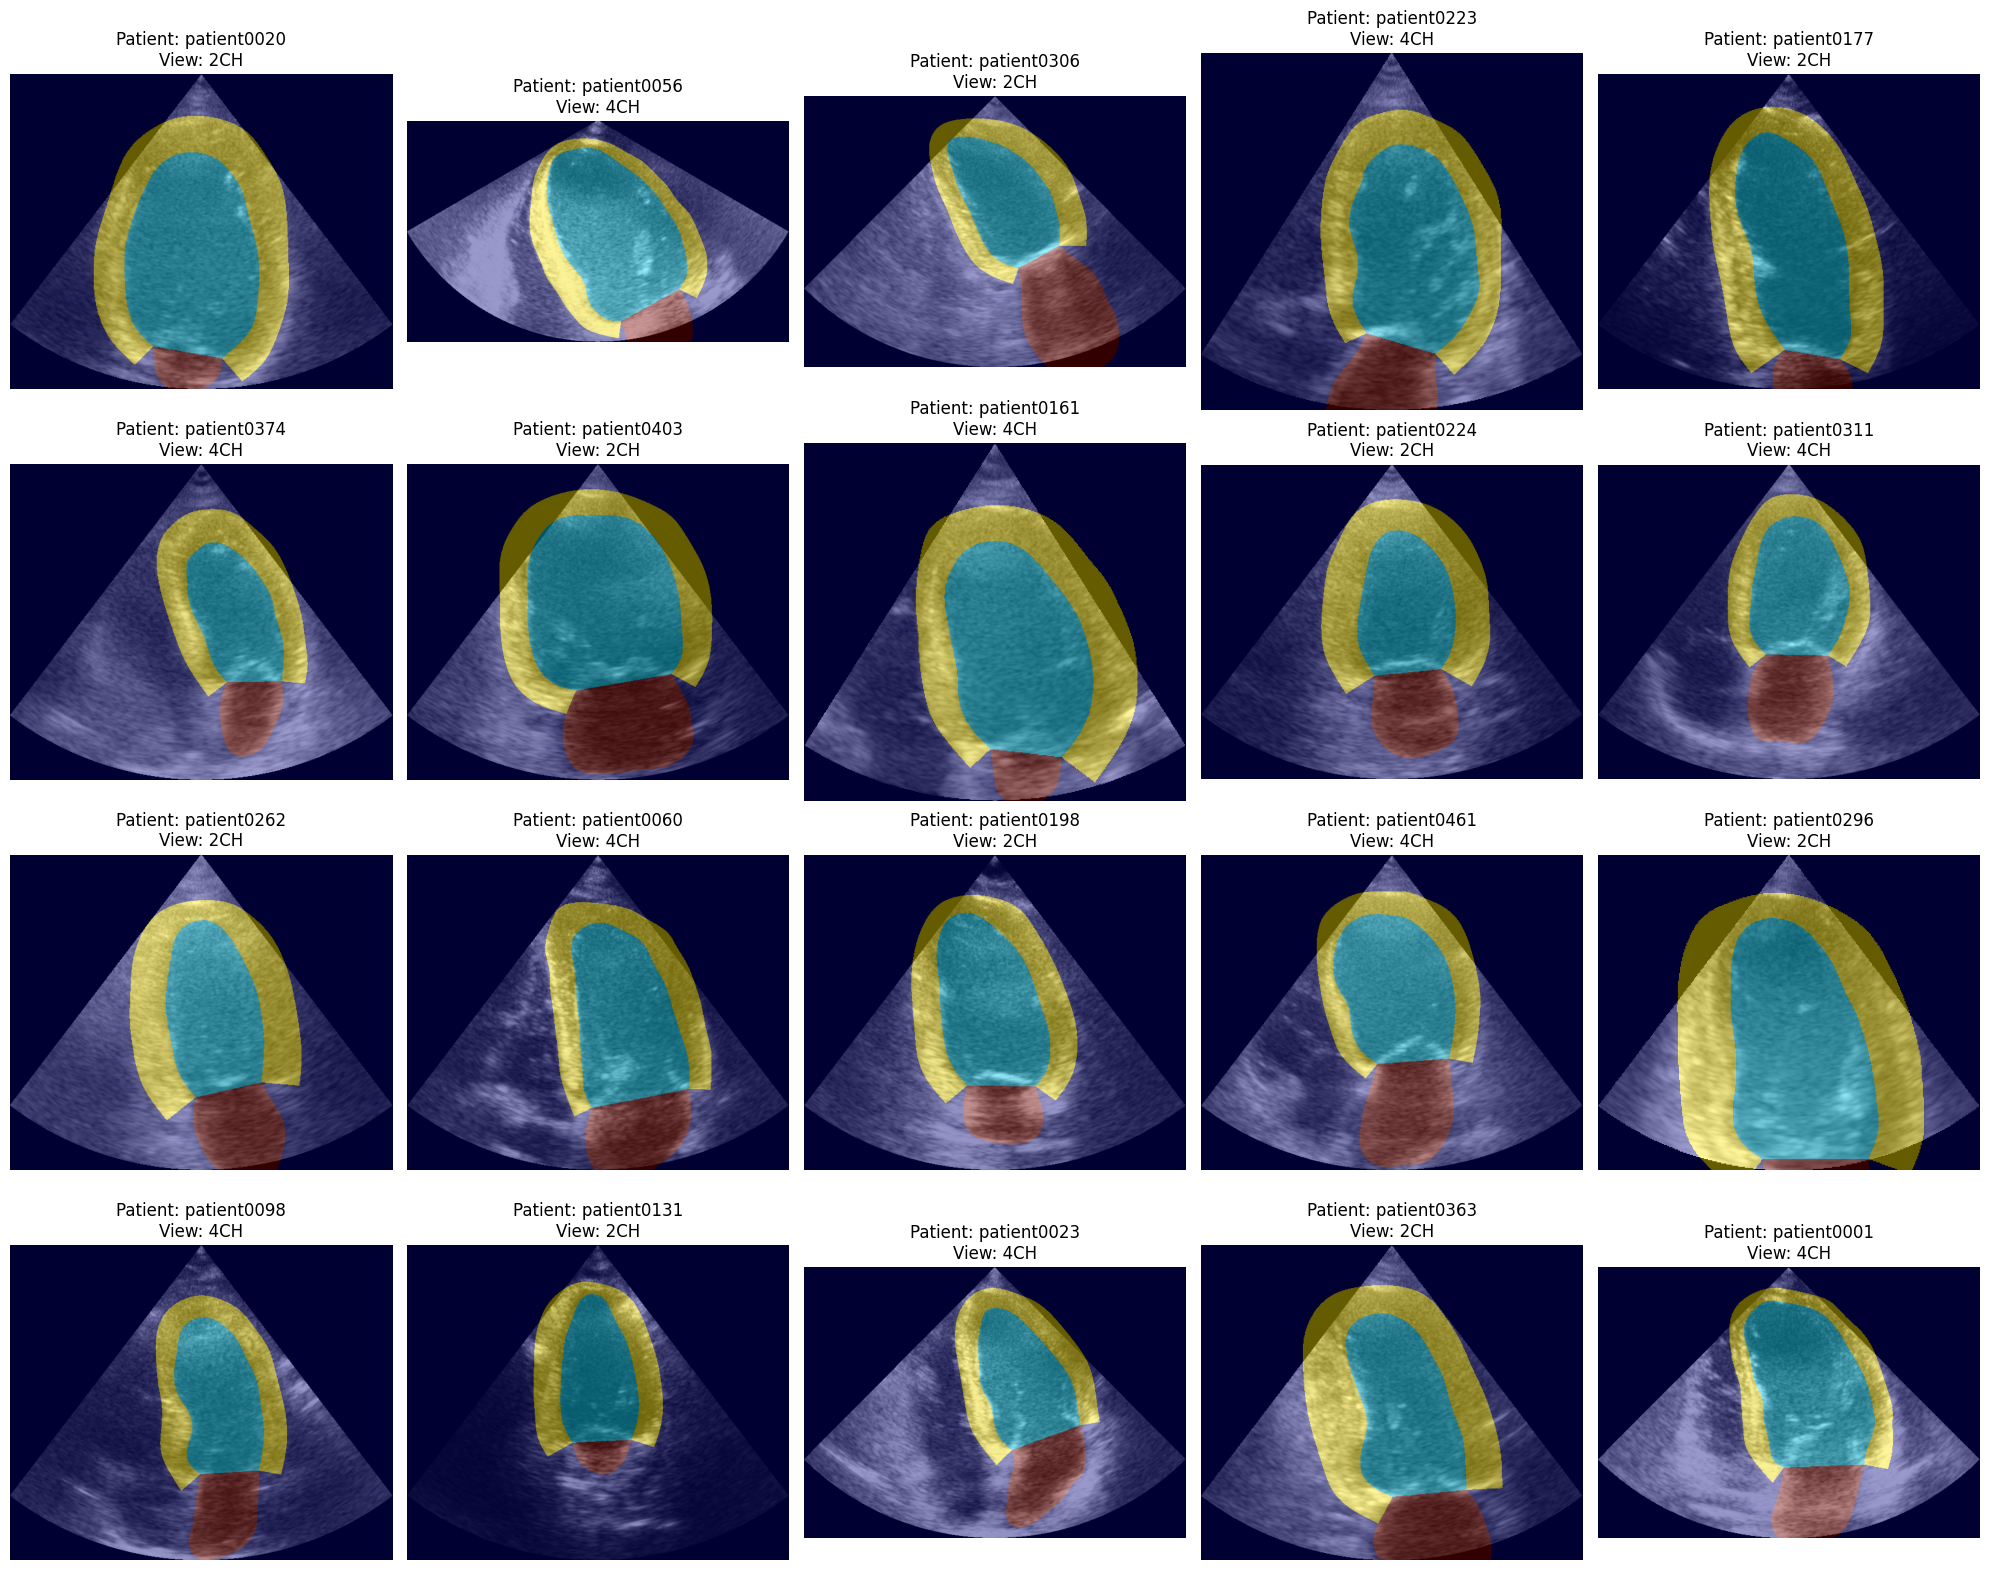

In [15]:
import matplotlib.pyplot as plt
import random
import os
import numpy as np
import SimpleITK as sitk

def visualize_cases(patient_list, base_path, num_cases=20):
    # Khtar 20 patient random
    selected_patients = random.sample(patient_list, num_cases)

    fig, axes = plt.subplots(4, 5, figsize=(20, 16))
    axes = axes.flatten()

    for i, p_id in enumerate(selected_patients):
        # Khtar view (2CH awla 4CH) b-t-tanawob
        view = "2CH" if i % 2 == 0 else "4CH"
        
        # Saggemt hna: raddit-ha p_id (mashi pid) bash t-matchi l-variable l-fouq
        img_path = os.path.join(base_path, p_id, f"{p_id}_{view}_ED.nii.gz")
        mask_path = os.path.join(base_path, p_id, f"{p_id}_{view}_ED_gt.nii.gz")

        # Loading & Squeezing (Lazém ykounou m-alignyin m3a l-for loop)
        img = np.squeeze(sitk.GetArrayFromImage(sitk.ReadImage(img_path)))
        mask = np.squeeze(sitk.GetArrayFromImage(sitk.ReadImage(mask_path)))

        # Plotting the Overlay
        axes[i].imshow(img, cmap='gray')
        # Overlay mask m3a transparency (alpha)
        axes[i].imshow(mask, cmap='jet', alpha=0.4) 
        axes[i].set_title(f"Patient: {p_id}\nView: {view}")
        axes[i].axis('off')

    plt.tight_layout()
    plt.show()

# Run visualization
# Sigur belli 'all_patients' w 'base_path' m-definiyin dakhél l-mémoire
visualize_cases(patients, base_path, num_cases=20)